In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA

import matplotlib.pyplot as plt

stock_data = yf.download("SPCX", interval="60m")

srs = stock_data['Close'].squeeze()
srs.index = srs.index.tz_localize(None) # drops timezone data


[*********************100%***********************]  1 of 1 completed


Text(0.5, 1.0, 'PACF')

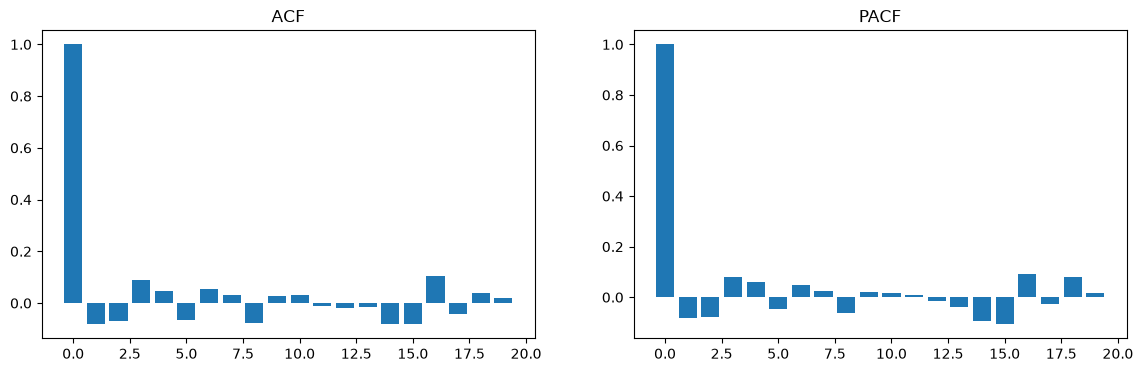

In [2]:
first_diff = srs.shift(1) - srs
first_diff = first_diff[1:]

num_lags = 20


acf_values = acf(first_diff) # represents MA component

pacf_values = pacf(first_diff) # represent AR component

fig, (bar1, bar2) = plt.subplots(1, 2, figsize=(14, 4))

bar1.bar(range(num_lags), acf_values[:num_lags])
bar1.set_title('ACF')

bar2.bar(range(num_lags), pacf_values[:num_lags])
bar2.set_title('PACF')


In [ ]:
model = ARIMA(first_diff, order=(1,0,1)) # ARMA(1,1)

fitted = model.fit()

print(fitted.summary())